# Sepsis early warning with jump diffusion features

Exploration notebook for the PhysioNet 2019 sepsis data. Run order:

1. `Compile_Sepsis_Data.py` (or the first cell below) builds `combined_sepsis_data.csv`.
2. This notebook builds jump and trend features, compares cohorts, and clusters septic patients.
3. `Fit_Jump_Diffusion.py` fits the pooled jump diffusion models.

This is work in progress and not a clinical tool.


In [1]:
import pandas as pd
import os
from pathlib import Path 

DATA_DIR = Path("data") / "training_setA"

OUTPUT_CSV = "combined_sepsis_data.csv"

OUTPUT_CSV_SAMPLE = "combined_sepsis_data_sample.csv"

def compile_all_patients(DATA_DIR):
    all_dfs = []
    if not Path(DATA_DIR).exists():
        raise FileNotFoundError(
            f"Could not find {DATA_DIR}. Download the PhysioNet 2019 training data "
            "and place the .psv files in this folder."
        )
    psv_files = list(Path(DATA_DIR).rglob("*.psv"))
    print(f"Found {len(psv_files)} patient files.")

    for i, filepath in enumerate(psv_files):
        patient_id = filepath.stem

        df = pd.read_csv(filepath, sep="|")
        df["patient_id"] = patient_id
        df["hour"] = df.index

        all_dfs.append(df)

        if(i+1) % 2000 == 0:
            print(f"  Loaded {i + 1} / {len(psv_files)} files...")
    
    combined = pd.concat(all_dfs, ignore_index=True)
    return combined

def main():
    combined = compile_all_patients(DATA_DIR)
 
    print(f"\nCombined dataset shape: {combined.shape[0]:,} rows x {combined.shape[1]} columns")
    print(f"Unique patients: {combined['patient_id'].nunique():,}")
    print(f"Sepsis-positive rows: {combined['SepsisLabel'].sum():,} "
          f"({100 * combined['SepsisLabel'].mean():.2f}% of all rows)")
 
    # Save the full combined dataset.
    combined.to_csv(OUTPUT_CSV, index=False)
    print(f"\nFull dataset saved to {OUTPUT_CSV}")
 
    # Save a small sample that is safe to open in Excel for a first look.
    combined.sample(n=min(50000, len(combined)), random_state=42).to_csv(
        OUTPUT_CSV_SAMPLE, index=False
    )
    print(f"A 50,000 row random sample saved to {OUTPUT_CSV_SAMPLE}")
 
 
if __name__ == "__main__":
    main()



Found 20336 patient files.
  Loaded 2000 / 20336 files...
  Loaded 4000 / 20336 files...
  Loaded 6000 / 20336 files...
  Loaded 8000 / 20336 files...
  Loaded 10000 / 20336 files...
  Loaded 12000 / 20336 files...
  Loaded 14000 / 20336 files...
  Loaded 16000 / 20336 files...
  Loaded 18000 / 20336 files...
  Loaded 20000 / 20336 files...

Combined dataset shape: 790,215 rows x 43 columns
Unique patients: 20,336
Sepsis-positive rows: 17,136 (2.17% of all rows)

Full dataset saved to combined_sepsis_data.csv
A 50,000 row random sample saved to combined_sepsis_data_sample.csv


In [2]:
df = pd.read_csv("combined_sepsis_data.csv")

onset_lookup = (df[df["SepsisLabel"] == 1].groupby("patient_id")["hour"].min().rename("onset_hour"))

print(f"Septic patients: {onset_lookup.shape[0]}")
print(onset_lookup.head())

missing_pct = df.isna().mean().sort_values(ascending=False)*100
print(missing_pct)


Septic patients: 1790
patient_id
p000009    248
p000011     24
p000015      5
p000018    125
p000022      9
Name: onset_hour, dtype: int64
EtCO2               100.000000
TroponinI            99.877881
Bilirubin_direct     99.850420
Fibrinogen           99.236917
Bilirubin_total      98.773372
Alkalinephos         98.540650
AST                  98.504205
Lactate              96.565112
PTT                  95.152459
SaO2                 95.044387
Calcium              95.024392
Phosphate            94.951247
Platelets            93.482913
Creatinine           93.357884
WBC                  92.489639
Magnesium            92.219712
HCO3                 91.949406
BUN                  91.840702
Chloride             91.676063
PaCO2                91.231753
Hgb                  91.164303
BaseExcess           89.574863
Potassium            89.137640
pH                   88.532868
Hct                  88.223711
Glucose              87.768392
FiO2                 85.807027
Temp                 66.

In [3]:
vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
df[vitals] = df.groupby('patient_id')[vitals].ffill()

for v in vitals:
    df[f'{v}_change'] = df.groupby('patient_id')[v].diff()

window_sizes = {'HR': 12, 'O2Sat': 12, 'SBP': 12, 'MAP': 12, 'Resp': 12, 'DBP': 12, 'Temp': 20}

for v in vitals:
    w = window_sizes[v]
    df[f'{v}_rolling_std'] = (df.groupby('patient_id')[f'{v}_change'].transform(lambda x: x.rolling(window=w, min_periods=3).std()))

for v in vitals:
    df[f'{v}_jump'] = (df[f'{v}_change'].abs() > 3 * df[f'{v}_rolling_std']).astype(int)

window = 12  # or vital-specific, as before

for v in vitals:
    df[f'{v}_rolling_trend'] = (
        df.groupby('patient_id')[v]
        .transform(lambda x: x.rolling(window=window, min_periods=6).mean().diff(window // 2))
    )

window = 12  # keep consistent with whatever window you used for the trend feature itself

for v in vitals:
    # each patient's own rolling std of their trend feature
    df[f'{v}_trend_std'] = (
        df.groupby('patient_id')[f'{v}_rolling_trend']
        .transform(lambda x: x.rolling(window=window, min_periods=3).std())
    )

    # flag when trend crosses a multiple of that patient's own trend variability
    df[f'{v}_trend_flag'] = (
        df[f'{v}_rolling_trend'].abs() > 2 * df[f'{v}_trend_std']
    ).astype(int)



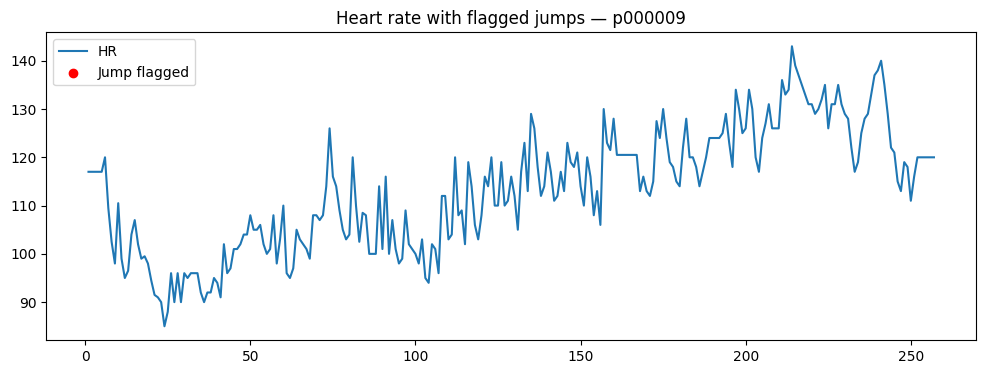

In [4]:
import matplotlib.pyplot as plt

patient = df[df['patient_id'] == 'p000009']  # pick one of your known septic patients
plt.figure(figsize=(12, 4))
plt.plot(patient['hour'], patient['HR'], label='HR')
plt.scatter(patient.loc[patient['HR_jump'] == 1, 'hour'],
            patient.loc[patient['HR_jump'] == 1, 'HR'],
            color='red', label='Jump flagged', zorder=5)
plt.legend()
plt.title('Heart rate with flagged jumps, p000009')
plt.show()

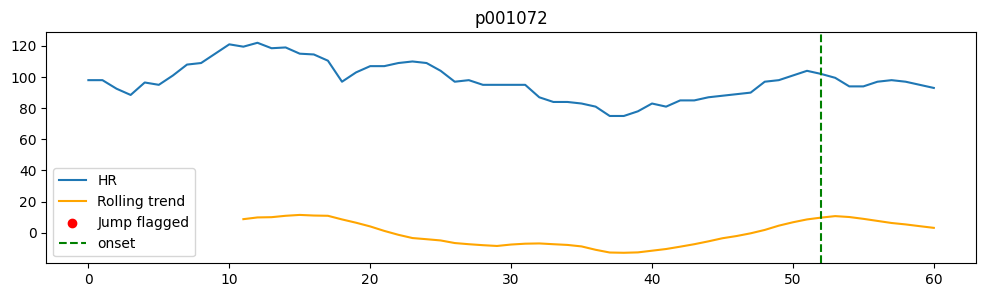

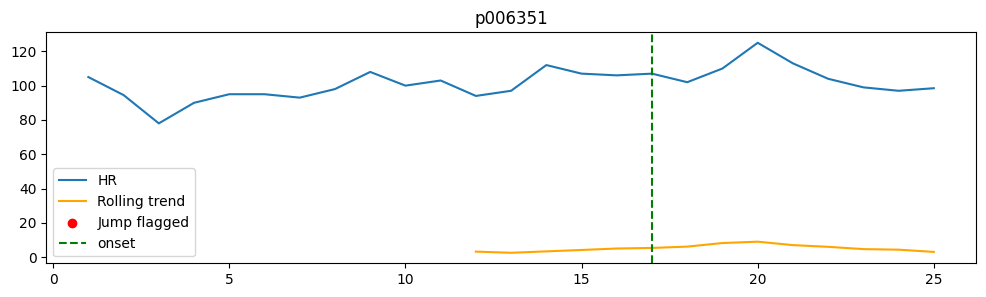

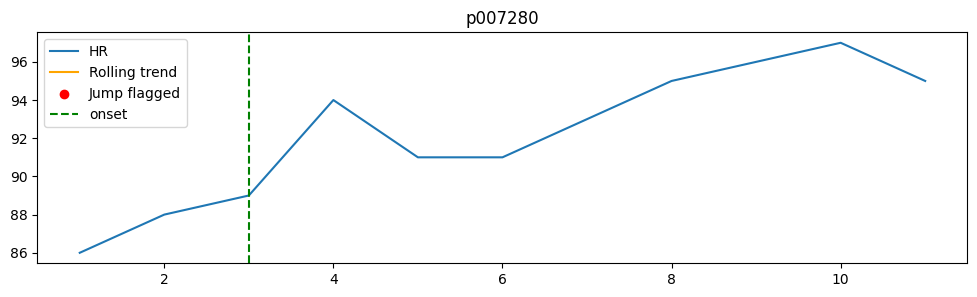

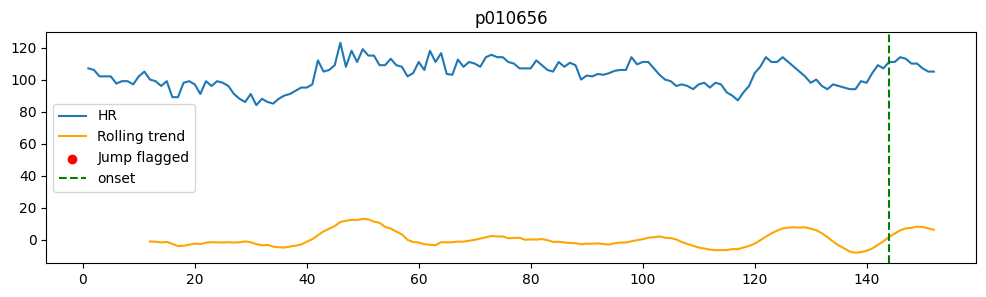

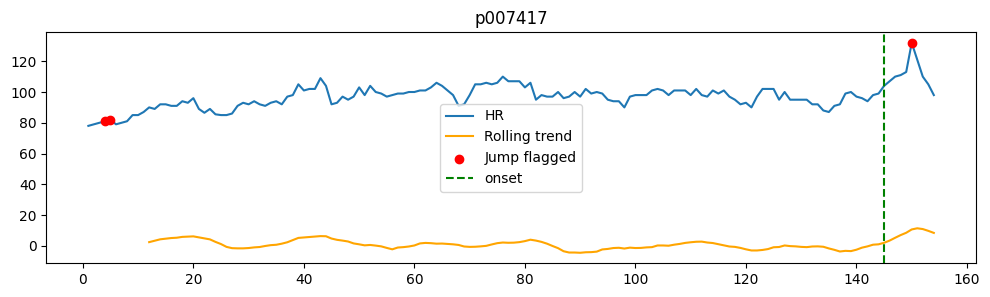

In [5]:
# check a handful of different septic patients, not just one
patients_with_history = onset_lookup[onset_lookup > 50].index
sample_septic = onset_lookup.sample(5, random_state=2).index

for pid in sample_septic:
    patient = df[df['patient_id'] == pid]
    plt.figure(figsize=(12, 3))

    plt.plot(patient['hour'], patient['HR'], label='HR', color='tab:blue')

    plt.plot(patient['hour'], patient['HR_rolling_trend'], 
              label='Rolling trend', color='orange', linestyle='-')

    plt.scatter(patient.loc[patient['HR_jump'] == 1, 'hour'],
                patient.loc[patient['HR_jump'] == 1, 'HR'],
                color='red', label='Jump flagged', zorder=5)

    plt.axvline(onset_lookup[pid], color='green', linestyle='--', label='onset')
    plt.title(f'{pid}')
    plt.legend()
    plt.show()


Median septic onset occurs at 75.7% of stay length
Septic cohort covariance:
              HR_change  O2Sat_change  Temp_change  SBP_change  MAP_change  \
HR_change     62.706209     -1.855321     0.119617   27.889140   23.268159   
O2Sat_change  -1.855321      5.618848    -0.009045    0.937934    0.671784   
Temp_change    0.119617     -0.009045     0.095672    0.030020   -0.028184   
SBP_change    27.889140      0.937934     0.030020  233.495676  128.507195   
MAP_change    23.268159      0.671784    -0.028184  128.507195  159.356832   
DBP_change    18.072338      0.476025     0.014146   86.297110   70.078801   
Resp_change    6.538847     -0.760102     0.023467    8.345888    5.886401   

              DBP_change  Resp_change  
HR_change      18.072338     6.538847  
O2Sat_change    0.476025    -0.760102  
Temp_change     0.014146     0.023467  
SBP_change     86.297110     8.345888  
MAP_change     70.078801     5.886401  
DBP_change     73.491816     4.666514  
Resp_change     4.

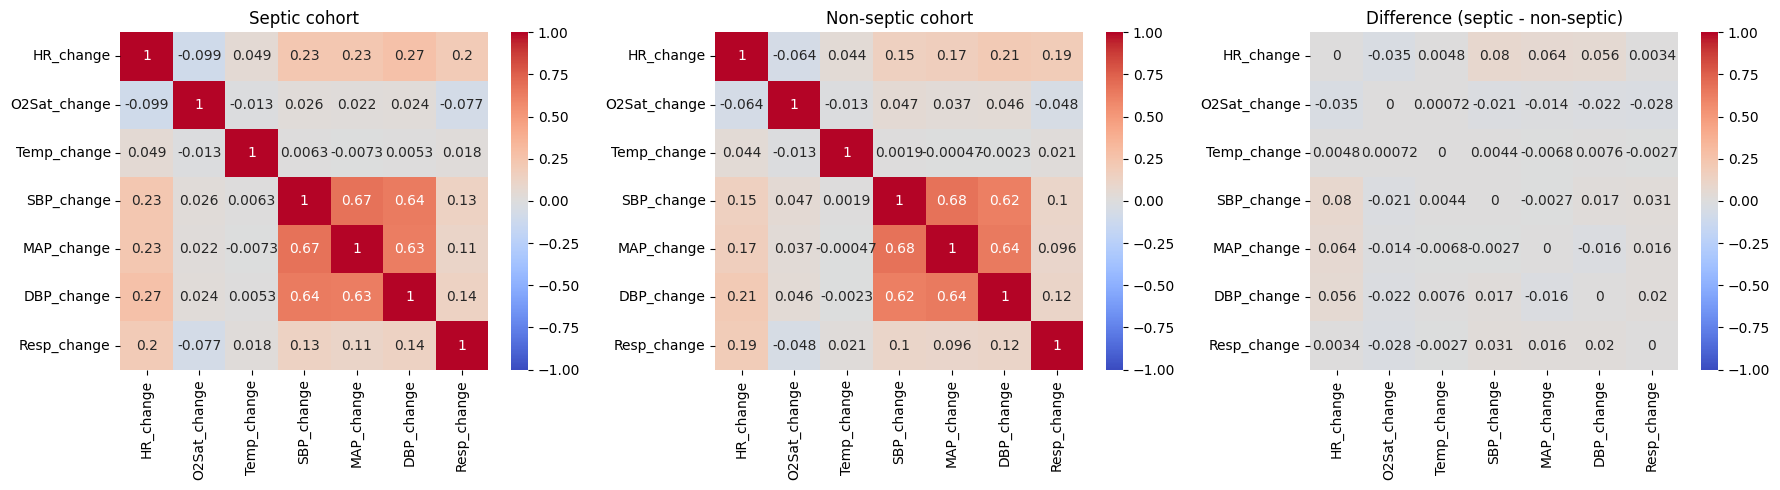

In [10]:
# septic patients: last 24 hours before onset
septic_ids = onset_lookup.index
septic_window = df[df['patient_id'].isin(septic_ids)].copy()
septic_window = septic_window.merge(onset_lookup, on='patient_id')
septic_window = septic_window[
    (septic_window['hour'] >= septic_window['onset_hour'] - 24) &
    (septic_window['hour'] < septic_window['onset_hour'])]

# --- Step 1: find each non-septic patient's stay length ---
stay_lengths = df.groupby('patient_id')['hour'].max().rename('stay_length')

# --- Step 2: find the typical onset percentile among septic patients ---
onset_with_stay = onset_lookup.to_frame().join(stay_lengths, on='patient_id')
onset_with_stay['onset_percentile'] = onset_with_stay['onset_hour'] / onset_with_stay['stay_length']
median_onset_pct = onset_with_stay['onset_percentile'].median()

print(f"Median septic onset occurs at {median_onset_pct:.1%} of stay length")

nonseptic_ids = df.loc[~df['patient_id'].isin(septic_ids), 'patient_id'].unique()

# --- Step 3: assign each non-septic patient a matched reference hour ---
nonseptic_stay = stay_lengths.loc[nonseptic_ids].rename('stay_length').to_frame()
nonseptic_stay['reference_hour'] = (nonseptic_stay['stay_length'] * median_onset_pct).round()

# --- Step 4: build the matched pre-reference window (same 24-hour logic as before) ---
nonseptic_window = df[df['patient_id'].isin(nonseptic_ids)].merge(
    nonseptic_stay[['reference_hour']], on='patient_id'
)
nonseptic_window = nonseptic_window[
    (nonseptic_window['hour'] >= nonseptic_window['reference_hour'] - 24) &
    (nonseptic_window['hour'] < nonseptic_window['reference_hour'])
]

# non-septic patients: any 24-hour window (placeholder until Phase B matching is built)


change_cols = [f'{v}_change' for v in vitals]

septic_cov = septic_window[change_cols].cov()
nonseptic_cov = nonseptic_window[change_cols].cov()

print("Septic cohort covariance:")
print(septic_cov)
print("\nNon-septic cohort covariance:")
print(nonseptic_cov)

septic_corr = septic_window[change_cols].corr()
nonseptic_corr = nonseptic_window[change_cols].corr()

diff = septic_corr - nonseptic_corr
print(diff)

import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(septic_corr, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, annot=True)
axes[0].set_title('Septic cohort')
sns.heatmap(nonseptic_corr, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, annot=True)
axes[1].set_title('Non-septic cohort')
sns.heatmap(diff, ax=axes[2], cmap='coolwarm', vmin=-1, vmax=1, annot=True)
axes[2].set_title('Difference (septic - non-septic)')
plt.tight_layout()
plt.show()



In [11]:
print(nonseptic_stay['reference_hour'].describe())
print(onset_with_stay['onset_hour'].describe())

count    18546.000000
mean        27.211366
std         10.351778
min          5.000000
25%         18.000000
50%         29.000000
75%         35.000000
max        254.000000
Name: reference_hour, dtype: float64
count    1790.000000
mean       49.065922
std        57.343113
min         0.000000
25%         7.000000
50%        28.000000
75%        71.000000
max       330.000000
Name: onset_hour, dtype: float64


### Earlier approach: fully individual fits

The next cell summarises an earlier run that fitted every patient separately. Many fits hit the boundary on the jump rate, which is why the project moved to pooled group fitting. That earlier fitting code is not included in this repository, so the cell is skipped if its output file is missing.


Total fits: 103740
Hit upper bound (~0.5): 12127 (11.7%)
Hit lower bound (~0): 42288 (40.8%)


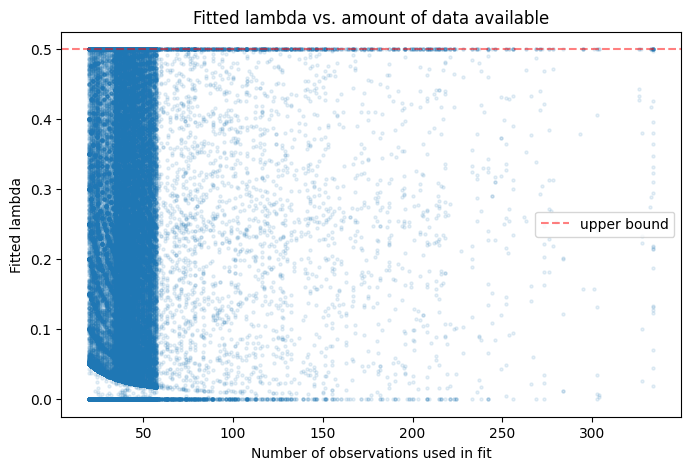

In [12]:
import os

if not os.path.exists("jump_diffusion_fitted_params.csv"):
    print("jump_diffusion_fitted_params.csv not found. This file came from the earlier, fully individual fitting run, which is not included in this repository.")
else:
    import pandas as pd
    import matplotlib.pyplot as plt

    fit_results = pd.read_csv("jump_diffusion_fitted_params.csv")

    # How many patient-vital fits hit the boundary exactly?
    at_upper_bound = (fit_results['lambda'] >= 0.499).sum()
    at_lower_bound = (fit_results['lambda'] <= 0.000002).sum()
    total = len(fit_results)

    print(f"Total fits: {total}")
    print(f"Hit upper bound (~0.5): {at_upper_bound} ({100*at_upper_bound/total:.1f}%)")
    print(f"Hit lower bound (~0): {at_lower_bound} ({100*at_lower_bound/total:.1f}%)")

    # Does boundary-hitting relate to how much data each patient had?
    plt.figure(figsize=(8, 5))
    plt.scatter(fit_results['n_obs'], fit_results['lambda'], alpha=0.1, s=5)
    plt.xlabel('Number of observations used in fit')
    plt.ylabel('Fitted lambda')
    plt.title('Fitted lambda vs. amount of data available')
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='upper bound')
    plt.legend()
    plt.show()

Loaded 790,215 rows, 20,336 patients, 1,790 septic.
(1587, 36)
               HR_mean     HR_std  HR_total_change  HR_jump_count  \
patient_id                                                          
p000009     113.036437  12.779425             -4.0            0.0   
p000011      87.333333   6.604785             19.0            0.0   
p000015      90.375000   4.956057              5.0            0.0   
p000018      96.278226  10.149553              6.0            0.0   
p000022      75.833333   6.828250             -9.0            0.0   

            HR_trend_max  O2Sat_mean  O2Sat_std  O2Sat_total_change  \
patient_id                                                            
p000009         7.166667   97.953441   1.873233                -2.0   
p000011         7.416667  100.000000   0.000000                 0.0   
p000015              NaN         NaN        NaN                 NaN   
p000018         8.666667   97.762097   2.186864                 0.0   
p000022              NaN   

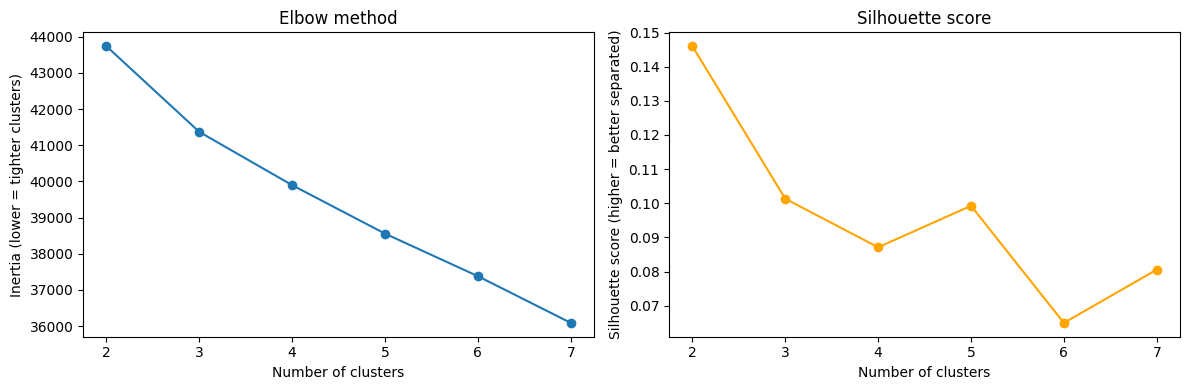

cluster
2    604
1    581
0    244
Name: count, dtype: int64
           HR_mean     HR_std  HR_total_change  HR_jump_count  HR_trend_max  \
cluster                                                                       
0        87.062822  11.687272         2.715164       0.913934     12.560176   
1        87.335645   6.536266        -2.520654       0.060241      1.323527   
2        88.436957   9.871927         2.913079       0.276490      8.245028   

         O2Sat_mean  O2Sat_std  O2Sat_total_change  O2Sat_jump_count  \
cluster                                                                
0         97.602173   2.136512           -0.377049          1.557377   
1         97.450375   1.500191           -0.401033          0.099828   
2         97.375208   2.054066           -0.673013          0.559603   

         O2Sat_trend_max  ...   DBP_std  DBP_total_change  DBP_jump_count  \
cluster                   ...                                               
0               2.340422  ..

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Load the compiled data (jump and trend features are rebuilt below) ---
df = pd.read_csv("combined_sepsis_data.csv")

vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

# --- Forward fill and hourly change columns ---
df[vitals] = df.groupby('patient_id')[vitals].ffill()
for v in vitals:
    df[f'{v}_change'] = df.groupby('patient_id')[v].diff()

# --- Jump flags (3 sigma threshold) ---
window_sizes = {'HR': 12, 'O2Sat': 12, 'SBP': 12, 'MAP': 12, 'Resp': 12, 'DBP': 12, 'Temp': 20}
for v in vitals:
    w = window_sizes[v]
    df[f'{v}_rolling_std'] = (
        df.groupby('patient_id')[f'{v}_change']
        .transform(lambda x: x.rolling(window=w, min_periods=3).std())
    )
    df[f'{v}_jump'] = (df[f'{v}_change'].abs() > 3 * df[f'{v}_rolling_std']).astype(int)

# --- Rolling trend ---
window = 12
for v in vitals:
    df[f'{v}_rolling_trend'] = (
        df.groupby('patient_id')[v]
        .transform(lambda x: x.rolling(window=window, min_periods=6).mean().diff(window // 2))
    )

# --- Onset lookup ---
onset_lookup = (
    df[df['SepsisLabel'] == 1]
    .groupby('patient_id')['hour']
    .min()
    .rename('onset_hour')
)
septic_ids = onset_lookup.index

print(f"Loaded {df.shape[0]:,} rows, {df['patient_id'].nunique():,} patients, {len(septic_ids):,} septic.")
# Widen the septic window for clustering to capture more of the trajectory
septic_window_wide = df[df['patient_id'].isin(septic_ids)].copy()
septic_window_wide = septic_window_wide.merge(onset_lookup, on='patient_id')
septic_window_wide = septic_window_wide[
    septic_window_wide['hour'] < septic_window_wide['onset_hour']
]  # everything before onset, no fixed cutoff

vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

def summarize_patient(group):
    summary = {}
    for v in vitals:
        valid_vals = group[v].dropna()
        summary[f'{v}_mean'] = group[v].mean()
        summary[f'{v}_std'] = group[v].std()
        summary[f'{v}_total_change'] = (valid_vals.iloc[-1] - valid_vals.iloc[0]) if len(valid_vals) > 1 else np.nan
        summary[f'{v}_jump_count'] = group[f'{v}_jump'].sum() if f'{v}_jump' in group.columns else 0
        summary[f'{v}_trend_max'] = group[f'{v}_rolling_trend'].max() if f'{v}_rolling_trend' in group.columns else np.nan
    summary['pre_onset_hours'] = len(group)
    return pd.Series(summary)

septic_summary = septic_window_wide.groupby('patient_id').apply(summarize_patient)
print(septic_summary.shape)
print(septic_summary.head())

from sklearn.preprocessing import StandardScaler

# Drop any patients with missing summary stats (e.g. too little data for std/trend)
nan_counts = septic_summary.isna().sum(axis=1)
septic_summary_filtered = septic_summary[nan_counts <= 10]
septic_summary_clean = septic_summary_filtered.fillna(0)
print(f"Kept {len(septic_summary_clean)} of {len(septic_summary)} patients (dropped {len(septic_summary) - len(septic_summary_filtered)} for having too little real data)")
print(f"Kept {len(septic_summary_clean)} of {len(septic_summary)} patients after dropping incomplete rows")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(septic_summary_clean)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Inertia (lower = tighter clusters)')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette score (higher = better separated)')
axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

final_k = 3  # chosen after looking at the elbow and silhouette plots

km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
septic_summary_clean['cluster'] = km_final.fit_predict(X_scaled)

print(septic_summary_clean['cluster'].value_counts())
print(septic_summary_clean.groupby('cluster').mean(numeric_only=True))



In [19]:
cluster_assignments = septic_summary_clean[['cluster']].reset_index()
cluster_assignments.to_csv("septic_cluster_assignments.csv", index=False)
print(f"Saved cluster assignments for {len(cluster_assignments)} patients.")

Saved cluster assignments for 1429 patients.


## Pooled jump diffusion fitting

The pooled fitting is slow, so it is run as a script instead of in this notebook.
After the cluster assignments are saved above, run this from a terminal:

```
python Fit_Jump_Diffusion.py
```

It writes `jump_diffusion_group_params.csv`, `jump_diffusion_patient_params.csv` and `combined_sepsis_data_with_jumpdiff.csv`.
